In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import jenkspy
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import confusion_matrix, classification_report


In [4]:
pip install jenkspy

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [19]:
# 1. Load your dataset
Flu_weather = pd.read_csv('NY_Flu_Weather_Final_Weekly.csv')

Flu_weather.head()

,County,Year,Month,Season,Region,Week,Week Ending Date,Disease,Infected,Avg household size,...,Latitude,Longitude,Prob_infected,County_Density,Ending Date,avg_temp_prior_week,avg_humidity_prior_week,avg_dew_point_prior_week,avg_precip_prior_week,avg_wind_speed_prior_week
0,ALBANY,2009,10,2009-2010,CAPITAL DISTRICT,40,10/10/2009,INFLUENZA_A,4,2.3,...,42.601,-73.977,0.000013,582.162575,2009-10-10,52.136235,75.422893,44.082307,0.082677,11.513748
1,ALBANY,2009,10,2009-2010,CAPITAL DISTRICT,40,10/10/2009,INFLUENZA_B,0,2.3,...,42.601,-73.977,0.000000,582.162575,2009-10-10,52.136235,75.422893,44.082307,0.082677,11.513748
2,ALBANY,2009,10,2009-2010,CAPITAL DISTRICT,40,10/10/2009,INFLUENZA_UNSPECIFIED,0,2.3,...,42.601,-73.977,0.000000,582.162575,2009-10-10,52.136235,75.422893,44.082307,0.082677,11.513748
3,ALBANY,2009,10,2009-2010,CAPITAL DISTRICT,41,10/17/2009,INFLUENZA_A,11,2.3,...,42.601,-73.977,0.000036,582.162575,2009-10-17,39.730165,68.109046,29.425700,0.042745,7.608064
4,ALBANY,2009,10,2009-2010,CAPITAL DISTRICT,41,10/17/2009,INFLUENZA_B,0,2.3,...,42.601,-73.977,0.000000,582.162575,2009-10-17,39.730165,68.109046,29.425700,0.042745,7.608064


In [21]:
def calculate_rsi(df):
    """
    Calculates the Resource Strain Index (RSI) based on weather stress factors.
    Assumes df contains: 'avg_temp', 'avg_humidity', and 'avg_dewpoint'
    """
    
    # 1. Define the 'Ideal' Maxima from your dataset 
    # (These should represent the warmest/most humid points in your data)
    T_max = df['avg_temp_prior_week'].max()
    H_max = df['avg_humidity_prior_week'].max()
    D_max = df['avg_dew_point_prior_week'].max()

    # 2. Calculate the Inversions
    # Lower temp/humidity/dewpoint = Higher Stress Score
    df['temp_stress'] = T_max - df['avg_temp_prior_week']
    df['hum_stress'] = H_max - df['avg_humidity_prior_week']
    df['dew_stress'] = D_max - df['avg_dew_point_prior_week']

    # 3. Aggregate into a single Index (RSI)
    # We take the mean of the three stress components
    df['RSI'] = (df['temp_stress'] + df['hum_stress'] + df['dew_stress']) / 3

    # Clean up intermediate columns to keep the dataframe lean
    df = df.drop(columns=['temp_stress', 'hum_stress', 'dew_stress'])
    
    return df

# Apply to your main dataframe
Flu_weather = calculate_rsi(Flu_weather)

print(f"RSI Range: {Flu_weather['RSI'].min():.2f} to {Flu_weather['RSI'].max():.2f}")

RSI Range: 4.36 to 57.66


In [22]:
#More feature engineering

def engineer_flu_features(df):
    # Sort by County and Date to ensure windows/lags are chronological
    # Assuming your dataframe has 'County' and 'Ending Date' columns
    df = df.sort_values(['County', 'Ending Date'])
    
    # --- 1. Cumulative Exposure (Sustained Environment) ---
    # We use a 4-week rolling mean to capture the 'Season' effect
    df['RSI_Sustained'] = df.groupby('County')['RSI'].transform(
        lambda x: x.rolling(window=4, min_periods=1).mean()
    )
    
    # --- 2. Rate of Change (The Shock) ---
    # Calculate how much the temperature dropped compared to last week
    # A negative value means it got colder (potential immune stress)
    df['Temp_Change_Velocity'] = df.groupby('County')['avg_temp_prior_week'].diff()
    
    # --- 3. Risk Windows (Based on your Charts) ---
    # Identifying the from EDA' risk windows where infection rates spike
    # Temp window: 15 to 35 | Dew Point window: 10 to 30
    df['In_Risk_Window'] = (
        (df['avg_temp_prior_week'].between(15, 35)) & 
        (df['avg_dew_point_prior_week'].between(10, 30))
    ).astype(int)
    
    # --- 4. RSI Volatility ---
    # High variance in weather can be more stressful than constant cold
    df['RSI_Volatility'] = df.groupby('County')['RSI'].transform(
        lambda x: x.rolling(window=3, min_periods=1).std()
    )
    
    return df

# Apply the function
Flu_weather = engineer_flu_features(Flu_weather)

# For Volatility (using 0 because there is no volatility in a single data point)
Flu_weather['Temp_Change_Velocity'] = Flu_weather.groupby('County')['Temp_Change_Velocity'].transform(lambda x: x.fillna(0))
Flu_weather['RSI_Volatility'] = Flu_weather.groupby('County')['RSI_Volatility'].transform(lambda x: x.fillna(0))

In [23]:
print(Flu_weather[['RSI', 'RSI_Sustained', 'Temp_Change_Velocity', 'In_Risk_Window', 'RSI_Volatility']].head())

         RSI  RSI_Sustained  Temp_Change_Velocity  In_Risk_Window  \
0  18.447291      18.447291               0.00000               0   
1  18.447291      18.447291               0.00000               0   
2  18.447291      18.447291               0.00000               0   
3  29.906132      21.312001             -12.40607               0   
4  29.906132      24.176712               0.00000               0   

   RSI_Volatility  
0        0.000000  
1        0.000000  
2        0.000000  
3        6.615765  
4        6.615765  


In [25]:
# infection probability rates may be lagged by a week or two 
# experiment with shifting the target variable back by 1-2 weeks to see if that improves the model's ability to predict spikes in infection rates

# creating a lagged target variable for the probability of infection
def create_lagged_targets(df, lags=[1, 2]):
    df = df.sort_values(['County', 'Ending Date'])
    
    for lag in lags:
        df[f'Prob_infected_lag_{lag}'] = (
            df.groupby('County')['Prob_infected'].shift(-lag)
        )
    
    return df

# applying to the main dataframe
Flu_weather = create_lagged_targets(Flu_weather, lags=[1, 2])

In [27]:
#  Existing Split
X = Flu_weather[['RSI', 'avg_precip_prior_week', 'avg_wind_speed_prior_week', 'RSI_Sustained', 'Temp_Change_Velocity', 'In_Risk_Window', 'RSI_Volatility']]
y = Flu_weather['Prob_infected']
y_log = np.log1p(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# 2. Define the Hybrid Groups
pca_features = ['RSI', 'RSI_Sustained', 'RSI_Volatility', 'avg_precip_prior_week', 'avg_wind_speed_prior_week']
raw_features = ['Temp_Change_Velocity', 'In_Risk_Window']

# 3. Scaling (Uses your X_train and X_test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[pca_features])
X_test_scaled = scaler.transform(X_test[pca_features])

# 4. PCA (Uses the scaled versions of your split)
pca = PCA(n_components=4)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# 5. Re-combining with Raw Features
# We use .index to ensure the PCA rows line up with the original Split rows
pca_cols = [f'PC{i+1}' for i in range(4)]
X_train_pca_df = pd.DataFrame(X_train_pca, columns=pca_cols, index=X_train.index)
X_test_pca_df = pd.DataFrame(X_test_pca, columns=pca_cols, index=X_test.index)

X_train_hybrid = pd.concat([X_train_pca_df, X_train[raw_features]], axis=1)
X_test_hybrid = pd.concat([X_test_pca_df, X_test[raw_features]], axis=1)


In [28]:
#Resampling

def rsi_undersample_fixed(X_hybrid, y_train, rsi_series, keep_fraction=0.20):
    """
    X_hybrid: The dataframe with PCA components and Raw features
    y_train: The log-transformed target
    rsi_series: The original RSI column from un-PCA'd X_train
    """
    
    # 1. Calculate threshold (Median of the RSI)
    threshold = rsi_series.median()
    
    # 2. Identify indices based on the RSI series
    # These indices match the index of X_hybrid because they both came from X_train
    weak_indices = rsi_series[rsi_series < threshold].index
    strong_indices = rsi_series[rsi_series >= threshold].index
    
    # 3. Randomly select which 'Weak' indices to keep
    n_to_keep = int(len(weak_indices) * keep_fraction)
    sampled_weak_indices = np.random.choice(weak_indices, size=n_to_keep, replace=False)
    
    # 4. Combine with ALL strong indices
    final_indices = np.concatenate([strong_indices, sampled_weak_indices])
    
    # 5. Use .loc to pull these rows from the hybrid features and target
    X_resampled = X_hybrid.loc[final_indices].sample(frac=1, random_state=42) # Shuffle
    y_resampled = y_train.loc[X_resampled.index] # Ensure target matches shuffled features
    
    print(f"RSI Threshold used: {threshold:.4f}")
    print(f"Kept {len(strong_indices)} strong weeks and {len(sampled_weak_indices)} weak weeks.")
    
    return X_resampled, y_resampled

# --- CALLING THE FUNCTION ---
# Pass the original 'RSI' series specifically so the function can find it
X_train_balanced, y_train_balanced = rsi_undersample_fixed(
    X_train_hybrid, 
    y_train_log, 
    rsi_series=X_train['RSI'], 
    keep_fraction=0.20
)

RSI Threshold used: 29.0783
Kept 23139 strong weeks and 4627 weak weeks.


In [43]:
# wrapping the entire pipeline into a function to easily test different lags
def run_pipeline_for_lag(df, lag):

    print(f"\n--- RUNNING MODEL WITH LAG = {lag} ---")

    # defining the target variable based on lag
    # lag = 0 means 1 week ahhead, lag = 1 means 2 weeks ahead, etc.
    if lag == 0:
        y = df['Prob_infected']
    else:
        y = df[f'Prob_infected_lag_{lag}']

    # drop rows where the target is NaN (due to lagging)
    valid_idx = y.notna()
    df_valid = df.loc[valid_idx].copy()

    # defining the used features - now aligned with the target variable and valid rows
    X = df_valid[['RSI', 'avg_precip_prior_week', 'avg_wind_speed_prior_week',
                  'RSI_Sustained', 'Temp_Change_Velocity',
                  'In_Risk_Window', 'RSI_Volatility']]

    y = y.loc[valid_idx]
    y_log = np.log1p(y)

    # splitting the data (80%/ 20%) with the lagged target variable
    X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

    # setting up the PCA and raw feature groups
    pca_features = ['RSI', 'RSI_Sustained', 'RSI_Volatility',
                    'avg_precip_prior_week', 'avg_wind_speed_prior_week']
    
    raw_features = ['Temp_Change_Velocity', 'In_Risk_Window']

    # scaling the PCA features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train[pca_features])
    X_test_scaled = scaler.transform(X_test[pca_features])

    # applying PCA to the scaled features
    pca = PCA(n_components=4)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    # re-combining the PCA components with the raw features
    pca_cols = [f'PC{i+1}' for i in range(4)]
    X_train_pca_df = pd.DataFrame(X_train_pca, columns=pca_cols, index=X_train.index)
    X_test_pca_df = pd.DataFrame(X_test_pca, columns=pca_cols, index=X_test.index)

    # concatenating PCA features with raw features to create the final hybrid dataset for modeling
    X_train_hybrid = pd.concat([X_train_pca_df, X_train[raw_features]], axis=1)
    X_test_hybrid = pd.concat([X_test_pca_df, X_test[raw_features]], axis=1)

    # applying the undersampling function to balance the dataset based on the RSI values
    X_train_balanced, y_train_balanced = rsi_undersample_fixed(
        X_train_hybrid,
        y_train_log,
        rsi_series=X_train['RSI'],
        keep_fraction=0.20
    )

    # training the gradient boosting regressor with the balanced dataset
    model = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=5,
        loss='quantile',
        alpha=0.7,
        random_state=42
    )

    # fitting the model on the balanced training data
    model.fit(X_train_balanced, y_train_balanced)

    # making predictions on the test set and evaluating the model's performance using Mean Absolute Error (MAE)
    preds_log = model.predict(X_test_hybrid)
    preds = np.expm1(preds_log)
    actual = np.expm1(y_test_log)

    mae = np.mean(np.abs(preds - actual))

    # printing the MAE for the current lag to compare performance across different lags
    print(f"Lag {lag} MAE: {mae:.6f}")

    return mae

In [44]:
# run the pipeline for different lags and store results
lag_results = {}

for lag in [0, 1, 2]:
    mae = run_pipeline_for_lag(Flu_weather, lag)
    lag_results[lag] = mae


--- RUNNING MODEL WITH LAG = 0 ---
RSI Threshold used: 29.0783
Kept 23139 strong weeks and 4627 weak weeks.
Lag 0 MAE: 0.000031

--- RUNNING MODEL WITH LAG = 1 ---
RSI Threshold used: 29.0906
Kept 23115 strong weeks and 4622 weak weeks.
Lag 1 MAE: 0.000034

--- RUNNING MODEL WITH LAG = 2 ---
RSI Threshold used: 29.0682
Kept 23089 strong weeks and 4617 weak weeks.
Lag 2 MAE: 0.000033


In [45]:
# comparing the results across lags
print("\n--- FINAL LAG COMPARISON ---")
for lag, score in lag_results.items():
    print(f"Lag {lag}: MAE = {score:.6f}")


--- FINAL LAG COMPARISON ---
Lag 0: MAE = 0.000031
Lag 1: MAE = 0.000034
Lag 2: MAE = 0.000033


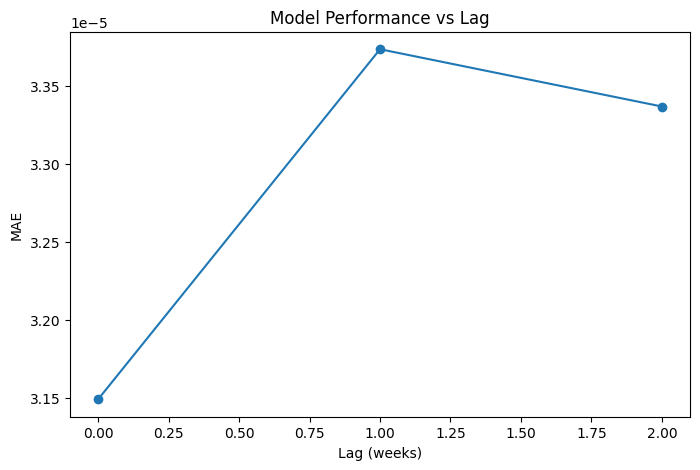

In [51]:
# plotting model performance vs lag to see if there is a clear improvement in prediiction accuracy with a certain lag
plt.figure(figsize=(8,5))
plt.plot(list(lag_results.keys()), list(lag_results.values()), marker='o')
plt.xlabel("Lag (weeks)")
plt.ylabel("MAE")
plt.title("Model Performance vs Lag")
plt.show()

In [ ]:
#### 
# FUNCTION run_pipeline_for_lag IS A COMPLETE END-TO-END PIPELINE THAT:
# 1. Takes the original dataframe and a specified lag for the target variable
# 2. Prepares the features and target variable based on the lag
# 3. Splits the data into training and testing sets
# 4. Applies PCA to the relevant features and combines them with raw features
# 5. Applies the undersampling function to balance the training dataset based on RSI values
# 6. Trains a Gradient Boosting Regressor on the balanced dataset
# 7. Evaluates the model's performance using Mean Absolute Error (MAE) and prints the results for each lag
####

In [ ]:
# CODE BELOW MAY NOT ALL BE NECESSARY FOR FINAL MODELS AND EVALUATIONS

In [34]:
# 3. The Ensemble Method: Gradient Boosting
# This is the 'Brain' that learns the weather-to-infection patterns
model_gb = GradientBoostingRegressor(
    n_estimators=100,    #Lower number of trees to prevent overfitting with limited features
    learning_rate=0.05, 
    max_depth=5, 
    loss='quantile',  #Using MAE to penalize underestimation more than MSE
    random_state=42, 
)


# commenting out for now
model_gb.fit(X_train_balanced, y_train_balanced)



# Try lagging different features to see if it improves the model
# Also add a loss function that penalizes underestimation more than overestimation, since underestimating risk is more dangerous in this context.
# Can also over sample the high-risk weeks to give the model more examples of those critical scenarios.
# In presentation explain how we come up with categories

GradientBoostingRegressor(learning_rate=0.05, loss='quantile', max_depth=5,
                          random_state=42)

In [35]:
# 1. Get predictions on your training set
train_preds = model_gb.predict(X_train_balanced) 

breaks = jenkspy.jenks_breaks(train_preds, n_classes=4)

print(f"Model-Derived Thresholds: {breaks}")


Model-Derived Thresholds: [np.float64(-2.599943655840126e-06), np.float64(4.736402919938345e-05), np.float64(0.0001545008823636474), np.float64(0.0002958053252541081), np.float64(0.0008698729058403383)]


/var/folders/r0/z_y4svtj4_11nn_kyp_dwyp80000gn/T/ipykernel_21513/1876142676.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = results.groupby('alert_level')['pred_prob'].mean()


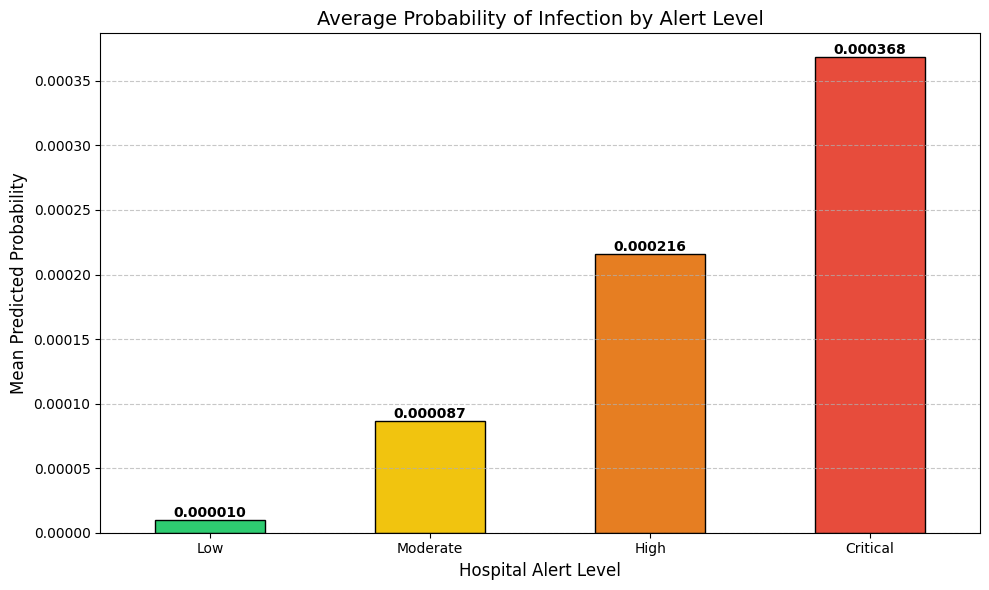

In [36]:
y_pred_probs = model_gb.predict(X_test_hybrid)  # Get predicted log probabilities
y_test_probs = np.expm1(y_test_log)  # Convert back to original scale for comparison

# Define the results DataFrame
# We align the actual values and predicted values side-by-side
results = pd.DataFrame({
    'actual_prob': y_test_probs,    # The real infection data from your test set
    'pred_prob': y_pred_probs  # What your model thinks the infection risk is
})


# 1. Define your specific thresholds and labels
# Note: I replaced the negative min with 0 for cleaner reporting
breaks = [0, 4.67898e-05, 0.000154293, 0.0002945734, 0.0008872]
labels = ['Low', 'Moderate', 'High', 'Critical']

# 2. Assign each prediction to a bin (Assuming 'results' is your DF)
# 'include_lowest=True' ensures the 0 value is caught in the first bin
results['alert_level'] = pd.cut(results['pred_prob'], bins=breaks, labels=labels, include_lowest=True)

# 3. Calculate the average probability for each bin
bin_stats = results.groupby('alert_level')['pred_prob'].mean()

# 4. Create the bar chart
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'] # Green, Yellow, Orange, Red
plt.figure(figsize=(10, 6))
bin_stats.plot(kind='bar', color=colors, edgecolor='black')

plt.title('Average Probability of Infection by Alert Level', fontsize=14)
plt.xlabel('Hospital Alert Level', fontsize=12)
plt.ylabel('Mean Predicted Probability', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels on top of bars
for i, v in enumerate(bin_stats):
    plt.text(i, v, f"{v:.6f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

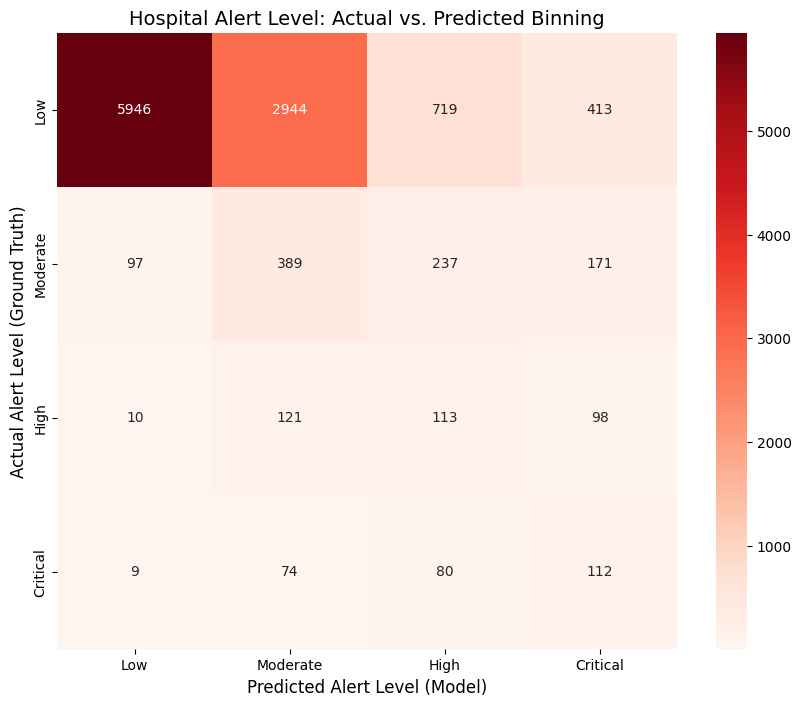

Classification Report for Hospital Bins:
              precision    recall  f1-score   support

         Low       0.14      0.41      0.21       275
    Moderate       0.10      0.33      0.15       342
        High       0.98      0.59      0.74     10022
    Critical       0.11      0.44      0.18       894

    accuracy                           0.57     11533
   macro avg       0.33      0.44      0.32     11533
weighted avg       0.87      0.57      0.67     11533



In [37]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Apply the binning to the ACTUAL data using the same breaks
results['actual_alert_level'] = pd.cut(
    results['actual_prob'], 
    bins=breaks, 
    labels=labels, 
    include_lowest=True
)

# 2. Drop any rows where actual_prob was outside the breaks range (NaNs)
# This prevents the 'str vs float' comparison error during the matrix generation
results_clean = results.dropna(subset=['alert_level', 'actual_alert_level'])

# 3. Generate the Confusion Matrix
# We explicitly set 'labels=labels' to ensure the order is Low -> Moderate -> High -> Critical
cm = confusion_matrix(results_clean['actual_alert_level'], results_clean['alert_level'], labels=labels)

# 4. Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=labels, yticklabels=labels)

plt.title('Hospital Alert Level: Actual vs. Predicted Binning', fontsize=14)
plt.xlabel('Predicted Alert Level (Model)', fontsize=12)
plt.ylabel('Actual Alert Level (Ground Truth)', fontsize=12)
plt.show()

# 5. Summary Statistics
print("Classification Report for Hospital Bins:")
print(classification_report(results_clean['actual_alert_level'], results_clean['alert_level'], target_names=labels))

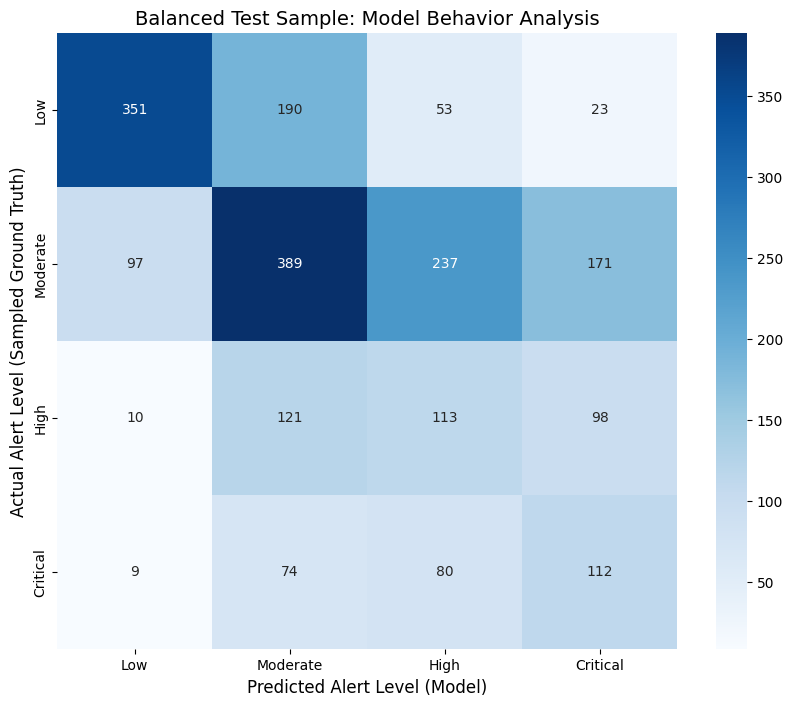

Sampled Classification Report (Balanced View):
              precision    recall  f1-score   support

         Low       0.28      0.41      0.33       275
    Moderate       0.23      0.33      0.27       342
        High       0.75      0.57      0.65       617
    Critical       0.50      0.44      0.47       894

    accuracy                           0.45      2128
   macro avg       0.44      0.44      0.43      2128
weighted avg       0.50      0.45      0.47      2128



In [40]:
# 1. Separate the results by their ACTUAL labels
# (We use results_clean since you already handled NaNs there)
df_critical = results_clean[results_clean['actual_alert_level'] == 'Critical']
df_high = results_clean[results_clean['actual_alert_level'] == 'High']
df_moderate = results_clean[results_clean['actual_alert_level'] == 'Moderate']
df_low = results_clean[results_clean['actual_alert_level'] == 'Low']

# 2. Determine a sample size
# To see a clear 'scientific' view, let's match the number of Lows to the number of Highs/Criticals
# This removes the 5000+ Lows that squeeze your heatmap
sample_size = len(df_high) + len(df_critical) 

# 3. Create the balanced subset
# We take all the rare cases and a 'human-readable' amount of the common ones
results_sampled = pd.concat([
    df_critical,
    df_high,
    df_moderate,
    df_low.sample(n=min(len(df_low), sample_size), random_state=42)
])

# 4. Generate the Sampled Confusion Matrix
cm_sampled = confusion_matrix(
    results_sampled['actual_alert_level'], 
    results_sampled['alert_level'], 
    labels=labels
)

# 5. Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm_sampled, annot=True, fmt='d', cmap='Blues', # Use Blue to distinguish from the 'Real' report
            xticklabels=labels, yticklabels=labels)

plt.title('Balanced Test Sample: Model Behavior Analysis', fontsize=14)
plt.xlabel('Predicted Alert Level (Model)', fontsize=12)
plt.ylabel('Actual Alert Level (Sampled Ground Truth)', fontsize=12)
plt.show()

# 6. Summary Statistics for the Sample
print("Sampled Classification Report (Balanced View):")
print(classification_report(
    results_sampled['actual_alert_level'], 
    results_sampled['alert_level'], 
    target_names=labels
))

In [41]:
import matplotlib.pyplot as plt

# Get feature importances from your trained model
importances = model.feature_importances_
feature_names = X_train_hybrid.columns

# Sort and Plot
indices = np.argsort(importances)
plt.title('Feature Importances: Hybrid PCA Model')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

NameError: name 'model' is not defined

In [42]:
import joblib

# Save everything needed for the pipeline
joblib.dump(model_gb, 'gb_model.pkl')
joblib.dump(scaler, 'data_scaler.pkl')
joblib.dump(pca, 'pca_transformer.pkl')

['pca_transformer.pkl']